# Import Libraries

Import Necessary libraries for build up a anomaly detection algorithm for credit card fraud detection.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
%matplotlib inline

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import DBSCAN
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.regularizers import l2

colors = sns.color_palette(['#00777F', '#5BABF5', '#AADEFE', '#EAAC9F', '#8AA0AF'])
sns.set_theme(context='notebook', style='darkgrid')

# Load Dataset

Load the dataset for credit card fraud detection using anomaly detection algorithm.he dataset contains 284,807 transactions with 31 features including:

Time: This shows how many seconds have passed since the first transaction in the dataset.



V1-V28: These are special features created to hide sensitive information about the original data.



Amount: Transaction amount.



Class: Target variable (0 for normal transactions, 1 for fraudulent transactions).

In [ ]:
data = pd.read_csv('/content/creditcard.csv')

In [ ]:
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# Feature Avilable

Analyze the dataset for applying anomaly detection algorithm

In [ ]:
data.shape

(284807, 31)

In [ ]:
data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
data.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
data.Class.value_counts()

,count
Class,
0,284315
1,492


# Visualize Fraud and Real Transaction

Visualize real and fraud transaction using pie chart

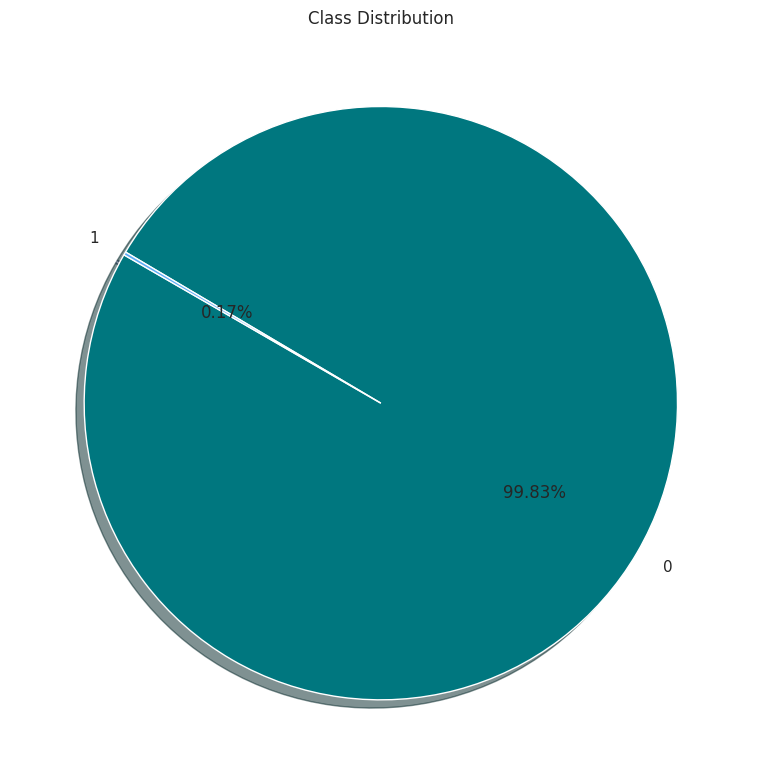

In [ ]:
target = data.Class.value_counts()

plt.figure(figsize=(8,8))
plt.pie(target, labels=target.index, autopct='%1.2f%%', colors=colors, startangle=150, shadow =True)

plt.title("Class Distribution")
plt.tight_layout()
plt.show()

# Features Transform

In this portion, i normalize all the feature in this dataset.Because These are special features(V1-V28) created to hide sensitive information about the original data.for using it, normalized this dataset is essential.

In [ ]:
features=data.columns[:-1]

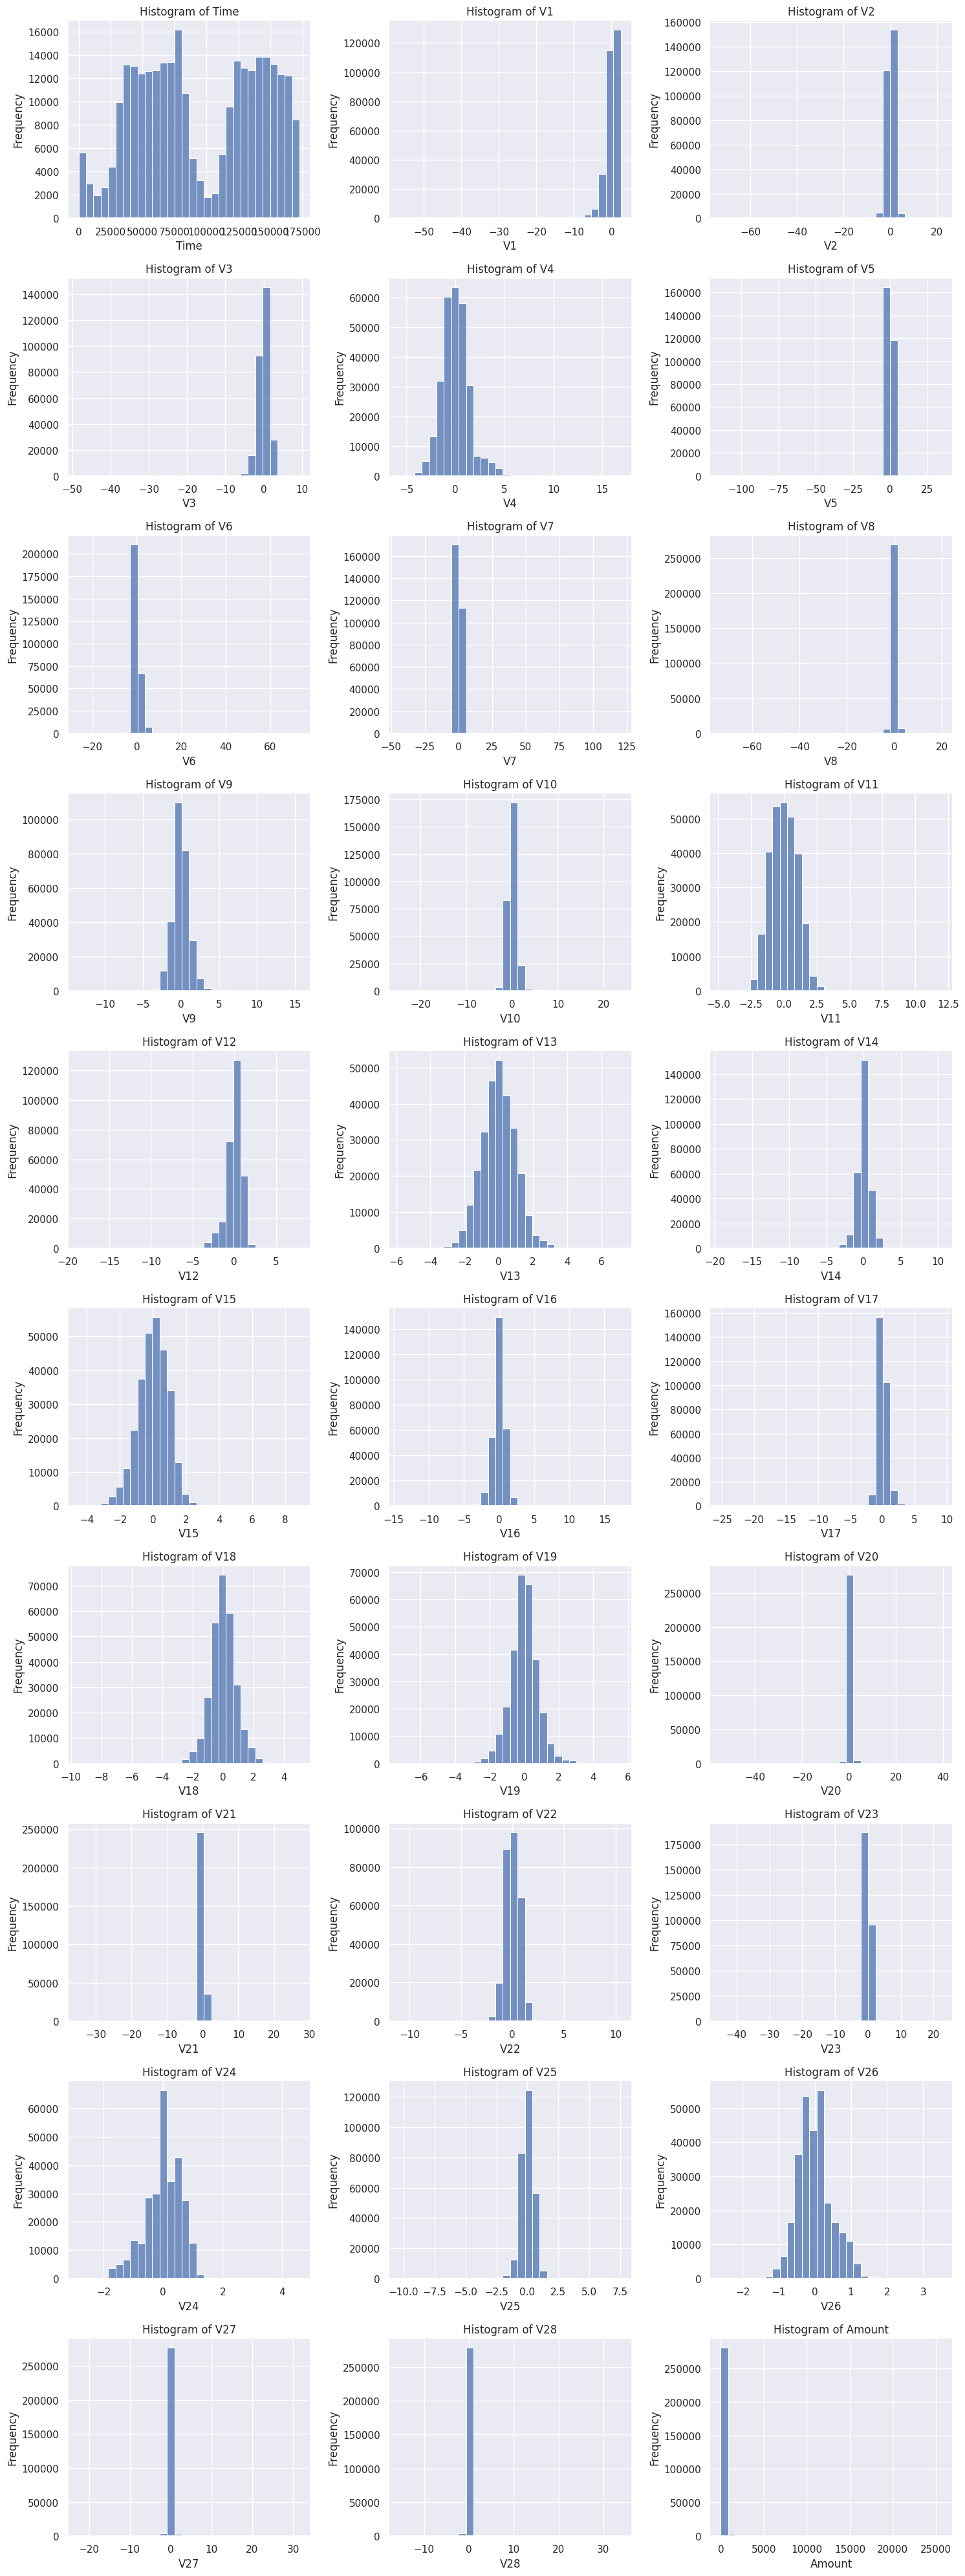

In [ ]:
fig, axes = plt.subplots(10, 3, figsize=(15,40))

axes = axes.flatten()

for i, feature in enumerate(features):
  sns.histplot(data[feature], ax=axes[i], kde=False, bins=30)
  axes[i].set_title(f'Histogram of {feature}')
  axes[i].set_xlabel(feature)
  axes[i].set_ylabel('Frequency')

for i in range(len(features), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [ ]:
data_transformed = data.copy()

def log_transformed_skewed(column):
  transformed = np.where(column >= 0, np.log1p(column), -np.log1p(-column))
  return transformed

skewness_before = data.skew()

for col in features:
  if abs(data[col].skew()) > 0.75:
      data_transformed[col] = log_transformed_skewed(data[col])

skewness_after = data_transformed.skew()

skewness_comparison = pd.DataFrame({'Skewness Before': skewness_before, 'Skewness After': skewness_after})

skewness_comparison

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


,Skewness Before,Skewness After
Time,-0.035568,-0.035568
V1,-3.280667,-0.364893
V2,-4.624866,-0.310128
V3,-2.240155,-0.315192
V4,0.676292,0.676292
V5,-2.425901,0.139077
V6,1.826581,0.804345
V7,2.553907,-0.112666
V8,-8.521944,-0.912642
V9,0.554680,0.554680


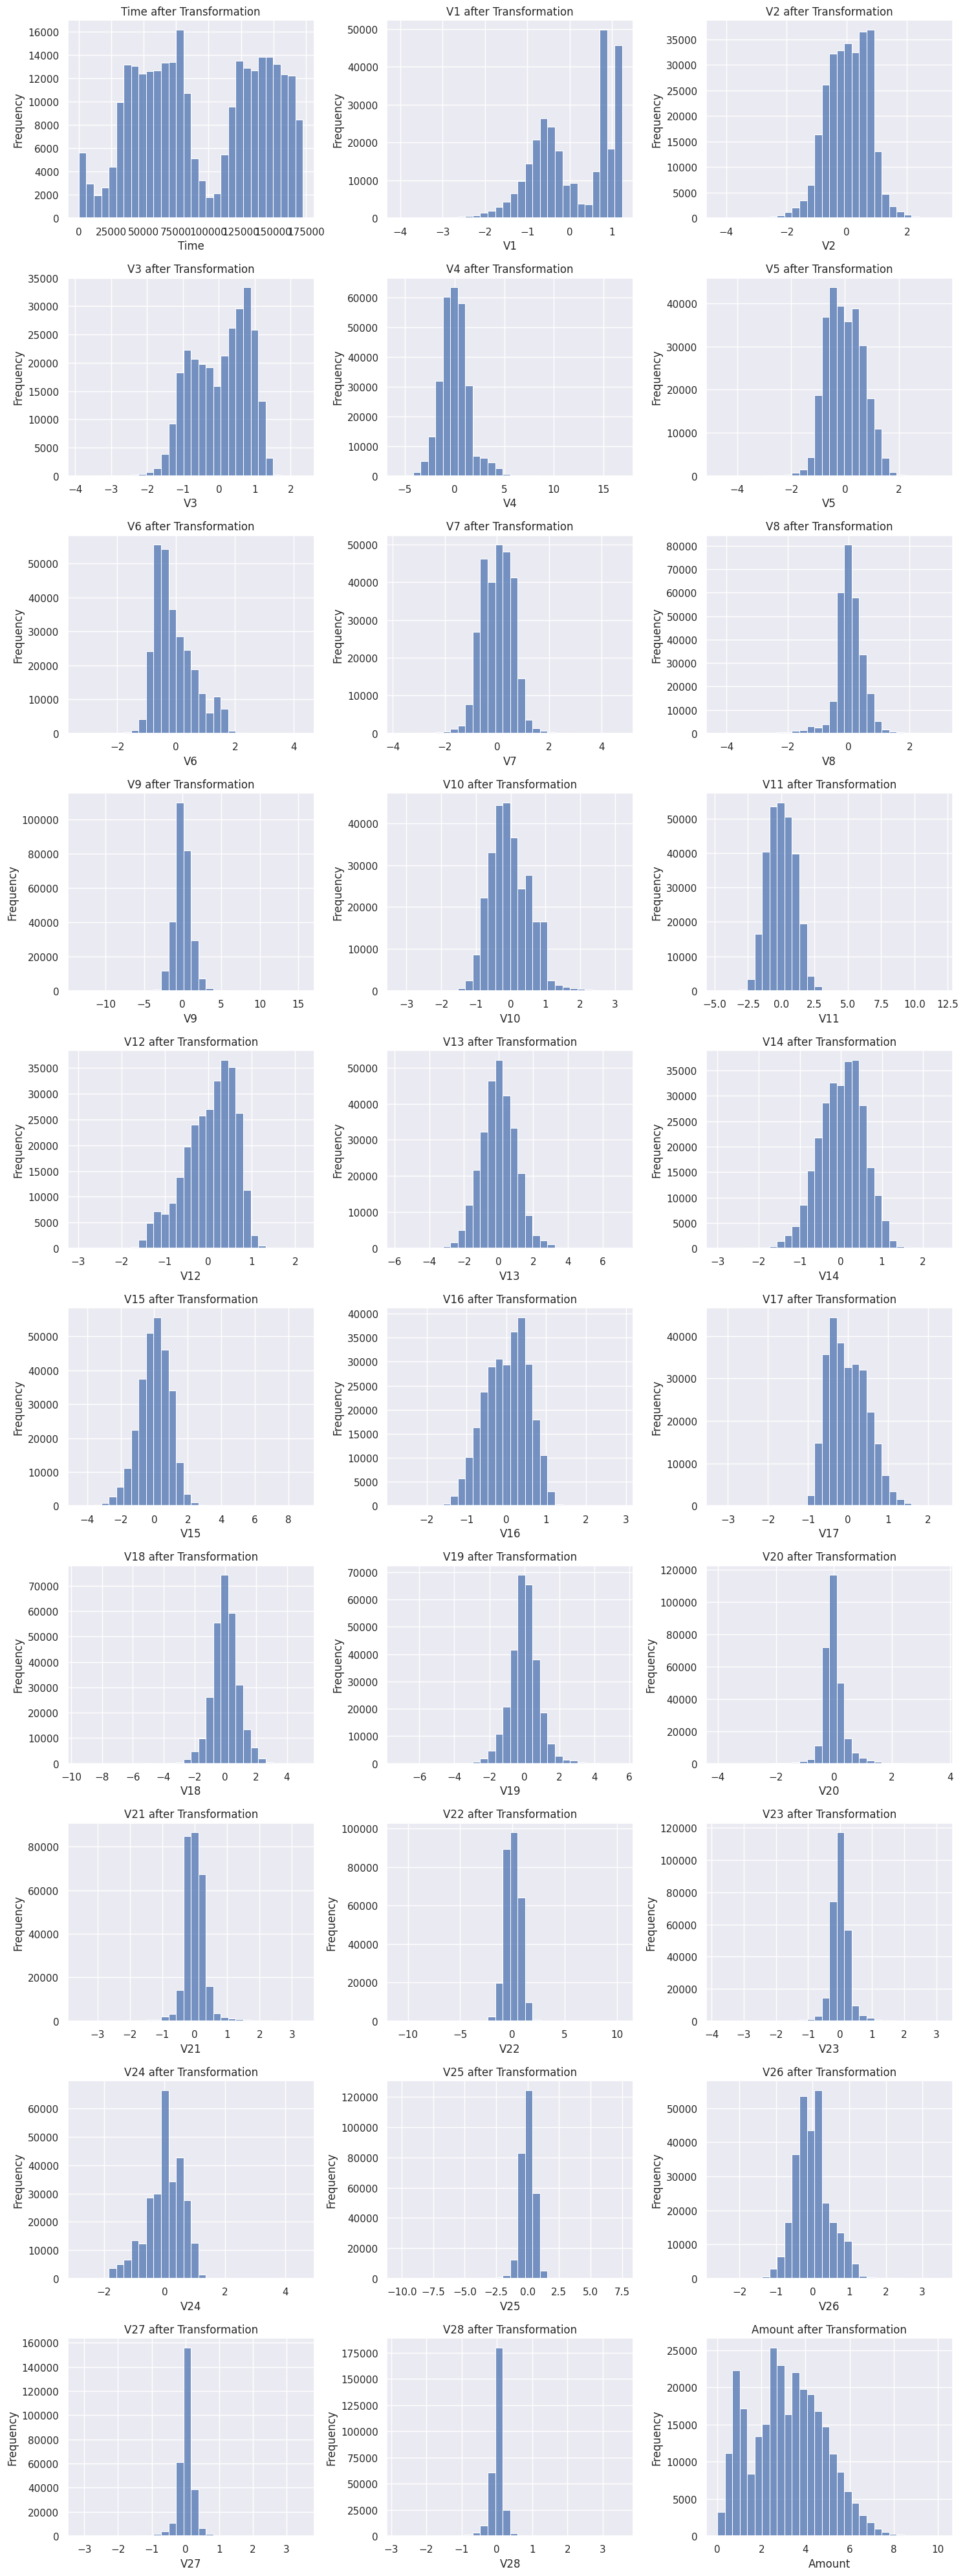

In [ ]:
fig, axes = plt.subplots(10, 3, figsize=(15,40))

axes = axes.flatten()

for i, feature in enumerate(features):
  sns.histplot(data_transformed[feature], ax=axes[i], kde=False, bins=30)
  axes[i].set_title(f'{feature} after Transformation')
  axes[i].set_xlabel(feature)
  axes[i].set_ylabel('Frequency')

for i in range(len(features), len(axes)):
    fig.delaxes(axes[i])
plt.tight_layout()
plt.show()

In [ ]:
 X = data_transformed[features]
 y = data_transformed.Class

 scaler = StandardScaler()
 X_scaled = scaler.fit_transform(X)

# Isolation Forest

This technique works by randomly selecting features and splitting data points.It's effective for large datasets, as it can quickly identify anomalies without needing to model the data's distribution.

In [ ]:
isolation_forest = IsolationForest(contamination='auto', random_state=101)
isolation_forest.fit(X_scaled)
isolation_preds = isolation_forest.predict(X_scaled)
isolation_preds = [1 if x == -1 else 0 for x in isolation_preds]

In [ ]:
print("Classification Report for Isolation Forest")
print(classification_report(y, isolation_preds))
roc_auc = roc_auc_score(y, isolation_preds)
print("ROC AUC Score: ", roc_auc)
print("Confusion Matrix for Isolation Forest")
print(confusion_matrix(y, isolation_preds))

Classification Report for Isolation Forest
              precision    recall  f1-score   support

           0       1.00      0.94      0.97    284315
           1       0.02      0.87      0.05       492

    accuracy                           0.94    284807
   macro avg       0.51      0.90      0.51    284807
weighted avg       1.00      0.94      0.97    284807

ROC AUC Score:  0.9041609815575847
Confusion Matrix for Isolation Forest
[[267380  16935]
 [    65    427]]


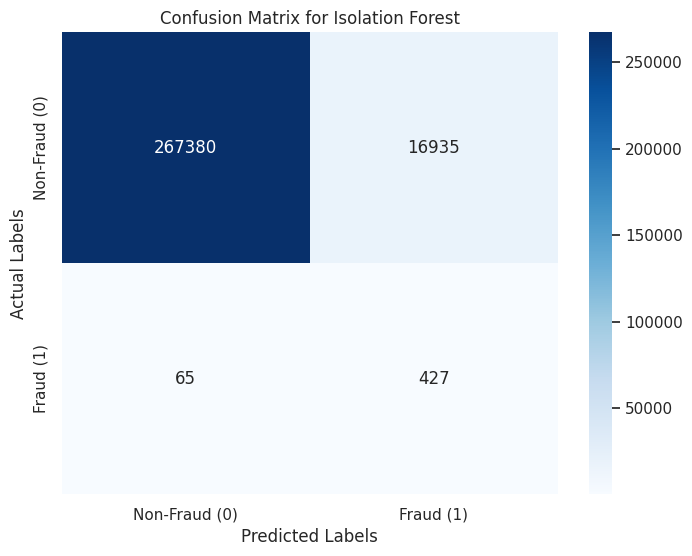

In [ ]:
cm = confusion_matrix(y, isolation_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title('Confusion Matrix for Isolation Forest')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.xticks([0.5, 1.5], ['Non-Fraud (0)', 'Fraud (1)'])
plt.yticks([0.5, 1.5], ['Non-Fraud (0)', 'Fraud (1)'])
plt.show()

ROC curve tells how well a classifier can distinguish between classes across all thresholds, and the AUC score quantifies this ability.

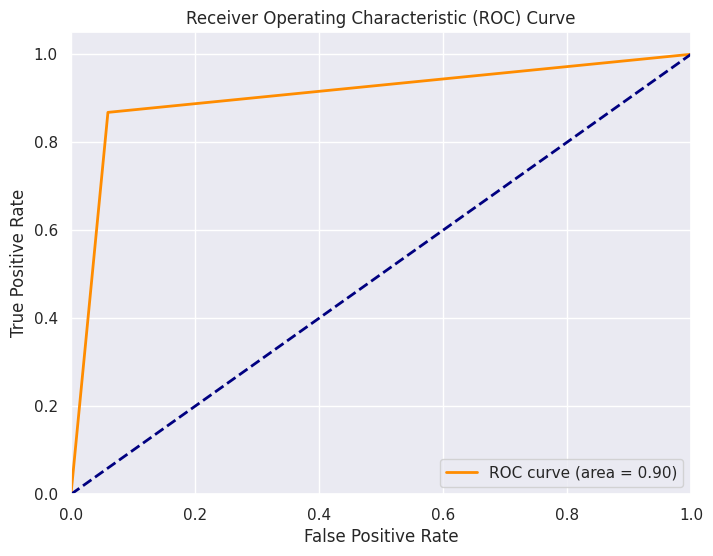

In [ ]:
fpr, tpr, thresholds = roc_curve(y, isolation_preds)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# DBSCAN

DBSCAN(Density-Based Spatial Clustering) groups data points based on their density, identifying clusters of similar points and marking isolated points as anomalies. This method is particularly effective at finding irregularly shaped clusters and can handle noise. However, it requires setting parameters like the distance threshold and the minimum number of points for clustering, which can be challenging and affect performance.

In [ ]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_preds = dbscan.fit_predict(X_scaled)
dbscan_preds = [1 if x == -1 else 0 for x in dbscan_preds]

print("Classification Report for DBScan")
print(classification_report(y, dbscan_preds))
roc_auc = roc_auc_score(y, dbscan_preds)
print("ROC AUC Score: ", roc_auc)
print("Confusion Matrix for DBScan")
print(confusion_matrix(y, dbscan_preds))

Classification Report for DBScan
              precision    recall  f1-score   support

           0       1.00      0.17      0.28    284315
           1       0.00      0.97      0.00       492

    accuracy                           0.17    284807
   macro avg       0.50      0.57      0.14    284807
weighted avg       1.00      0.17      0.28    284807

ROC AUC Score:  0.568390228746914
Confusion Matrix for DBScan
[[ 46979 237336]
 [    14    478]]


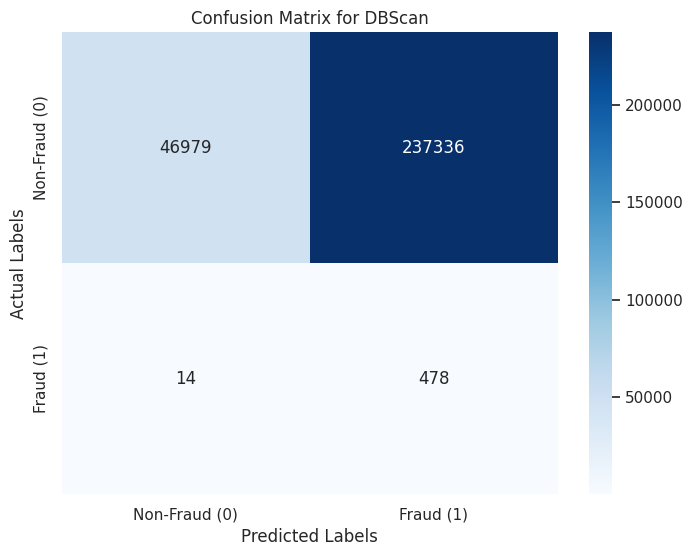

In [ ]:
cm = confusion_matrix(y, dbscan_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title('Confusion Matrix for DBScan')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.xticks([0.5, 1.5], ['Non-Fraud (0)', 'Fraud (1)'])
plt.yticks([0.5, 1.5], ['Non-Fraud (0)', 'Fraud (1)'])
plt.show()

ROC curve tells how well a classifier can distinguish between classes across all thresholds, and the AUC score quantifies this ability.

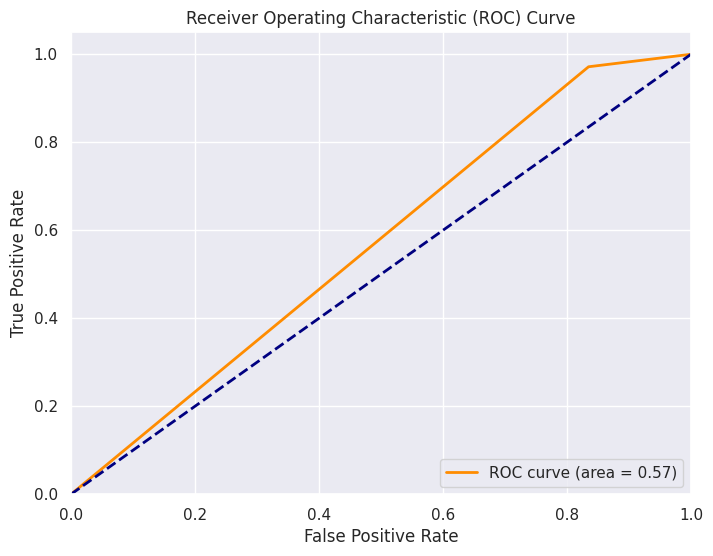

In [ ]:
fpr, tpr, thresholds = roc_curve(y, dbscan_preds)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# Local Outlier Factor

LOF(Local Outlier Factor) assesses the local density of each data point compared to its neighbors. If a point has a significantly lower density than those around it, it's considered an outlier.Because DBSCAN and Isolation Forest analyze this point, which is far away for this dataset.

In [ ]:
loc = LocalOutlierFactor(n_neighbors=20, contamination='auto')
loc_preds = loc.fit_predict(X_scaled)
loc_preds = [1 if x == -1 else 0 for x in loc_preds]

In [ ]:
print("Classification Report for Local Outlier Factor")
print(classification_report(y, loc_preds))
roc_auc = roc_auc_score(y, loc_preds)
print("ROC AUC Score: ", roc_auc)
print("Confusion Matrix for Local Outlier Factor")
print(confusion_matrix(y, loc_preds))

Classification Report for Local Outlier Factor
              precision    recall  f1-score   support

           0       1.00      0.96      0.98    284315
           1       0.00      0.10      0.01       492

    accuracy                           0.96    284807
   macro avg       0.50      0.53      0.49    284807
weighted avg       1.00      0.96      0.98    284807

ROC AUC Score:  0.5287676921095047
Confusion Matrix for Local Outlier Factor
[[273513  10802]
 [   445     47]]


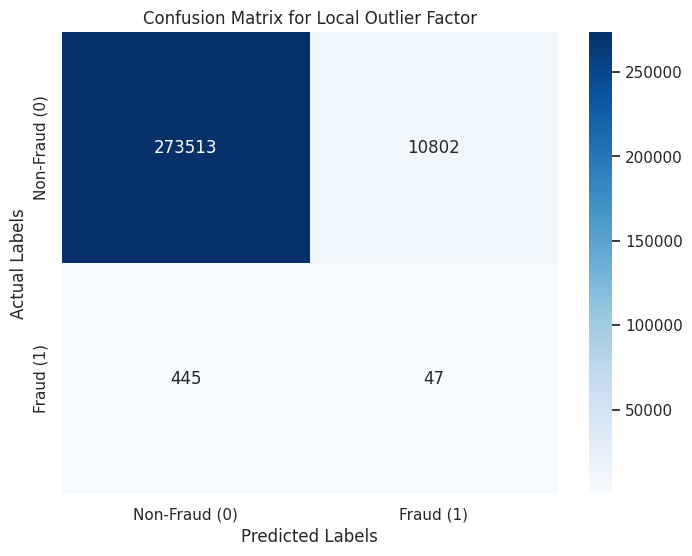

In [ ]:
cm = confusion_matrix(y, loc_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title('Confusion Matrix for Local Outlier Factor')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.xticks([0.5, 1.5], ['Non-Fraud (0)', 'Fraud (1)'])
plt.yticks([0.5, 1.5], ['Non-Fraud (0)', 'Fraud (1)'])
plt.show()

ROC curve tells how well a classifier can distinguish between classes across all thresholds, and the AUC score quantifies this ability.

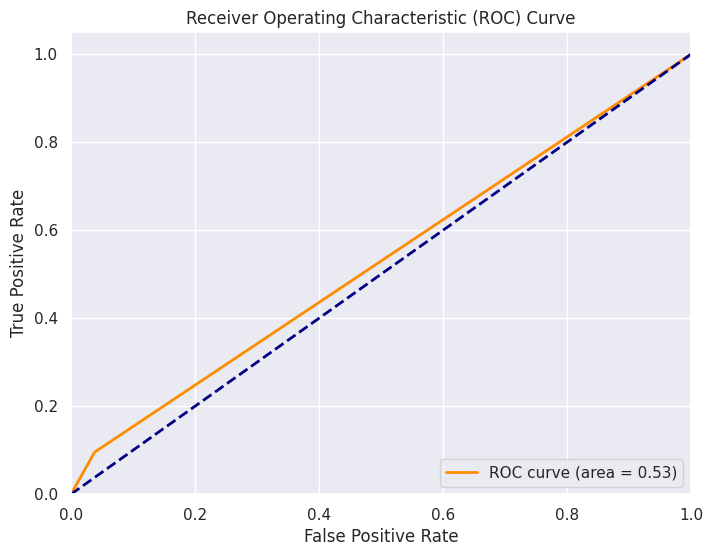

In [ ]:
fpr, tpr, thresholds = roc_curve(y, loc_preds)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# Autoencoder

These are neural networks designed to compress and reconstruct data. By training on normal transactions, they learn to recreate them effectively. If a transaction cannot be reconstructed well, it's flagged as an anomaly. Autoencoders are great for capturing complex patterns in data, but they require more computational resources and careful tuning of architecture and parameters to perform effectively.

In [ ]:
def build_autoencoder(input_dim):
  input_layer = Input(shape=(input_dim,))
  encoded = Dense(32, activation='relu', kernel_regularizer=l2(0.001))(input_layer)
  encoded = Dropout(0.2)(encoded)
  encoded = Dense(16, activation='relu', kernel_regularizer=l2(0.001))(encoded)
  encoded = Dense(8, activation='relu', kernel_regularizer=l2(0.001))(encoded)

  latent = Dense(4, activation='relu')(encoded)

  decoded = Dense(8, activation='relu', kernel_regularizer=l2(0.001))(latent)
  decoded = Dropout(0.2)(decoded)
  decoded = Dense(16, activation='relu', kernel_regularizer=l2(0.001))(decoded)
  decoded = Dense(32, activation='relu', kernel_regularizer=l2(0.001))(decoded)
  output_layer = Dense(input_dim, activation='linear')(decoded)

  autoencoder = Model(inputs=input_layer, outputs=output_layer)
  return autoencoder

autoencoder = build_autoencoder(X_scaled.shape[1])
autoencoder.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss='mse')

X_train = X_scaled[y == 0]
autoencoder.fit(X_train, X_train, epochs=50, batch_size=32, shuffle=True, validation_split=0.1)

Epoch 1/50
7997/7997 ━━━━━━━━━━━━━━━━━━━━ 24s 3ms/step - loss: 1.0067 - val_loss: 0.8690
Epoch 2/50
7997/7997 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - loss: 0.8934 - val_loss: 0.8491
Epoch 3/50
7997/7997 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - loss: 0.8617 - val_loss: 0.8396
Epoch 4/50
7997/7997 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 0.8450 - val_loss: 0.8320
Epoch 5/50
7997/7997 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - loss: 0.8380 - val_loss: 0.8250
Epoch 6/50
7997/7997 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - loss: 0.8311 - val_loss: 0.8122
Epoch 7/50
7997/7997 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - loss: 0.8221 - val_loss: 0.8127
Epoch 8/50
7997/7997 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - loss: 0.8202 - val_loss: 0.8040
Epoch 9/50
7997/7997 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - loss: 0.8143 - val_loss: 0.8062
Epoch 10/50
7997/7997 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - loss: 0.8123 - val_loss: 0.8017
Epoch 11/50
7997/7997 ━━━━━━━━━━━━━━━━━━━━ 44s 3ms/step - loss: 0.8117 - val_loss: 0.8008
Epoch 12/50
7997/79

In [ ]:
reconstructed = autoencoder.predict(X_scaled)
mse = np.mean(np.power(X_scaled - reconstructed, 2), axis=1)
threshold = np.percentile(mse, 90)
autoen_preds = np.where(mse > threshold, 1, 0)
print("Classification Report for Autoencoder")
print(classification_report(y, autoen_preds))
roc_auc = roc_auc_score(y, autoen_preds)
print("ROC AUC Score: ", roc_auc)

8901/8901 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step
Classification Report for Autoencoder
              precision    recall  f1-score   support

           0       1.00      0.90      0.95    284315
           1       0.01      0.87      0.03       492

    accuracy                           0.90    284807
   macro avg       0.51      0.88      0.49    284807
weighted avg       1.00      0.90      0.95    284807

ROC AUC Score:  0.8846069657652418


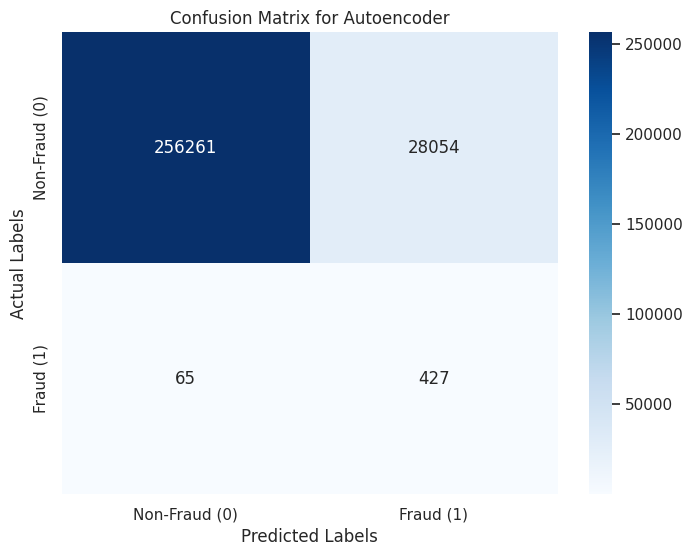

In [ ]:
cm = confusion_matrix(y, autoen_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title('Confusion Matrix for Autoencoder')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.xticks([0.5, 1.5], ['Non-Fraud (0)', 'Fraud (1)'])
plt.yticks([0.5, 1.5], ['Non-Fraud (0)', 'Fraud (1)'])
plt.show()

ROC curve tells how well a classifier can distinguish between classes across all thresholds, and the AUC score quantifies this ability.

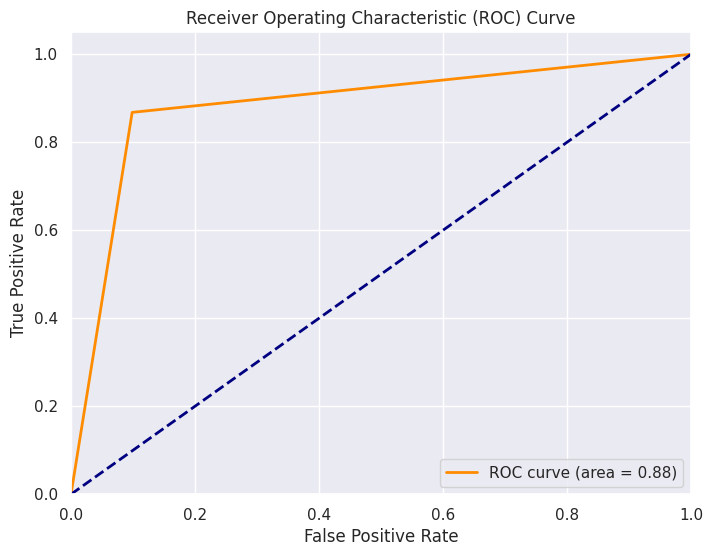

In [ ]:
fpr, tpr, thresholds = roc_curve(y, autoen_preds)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()